In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import squarify

In [3]:
df=pd.read_csv('age_salary_hours.csv')

In [6]:
education_counts = df['Education'].value_counts()
order = [
    'No diploma',
    'Attended college, no degree',
    "Associate's degree",
    'High school diploma',
    "Bachelor's degree or higher"
]
education_counts = education_counts.reindex(order)
education_percent = education_counts / education_counts.sum() * 100

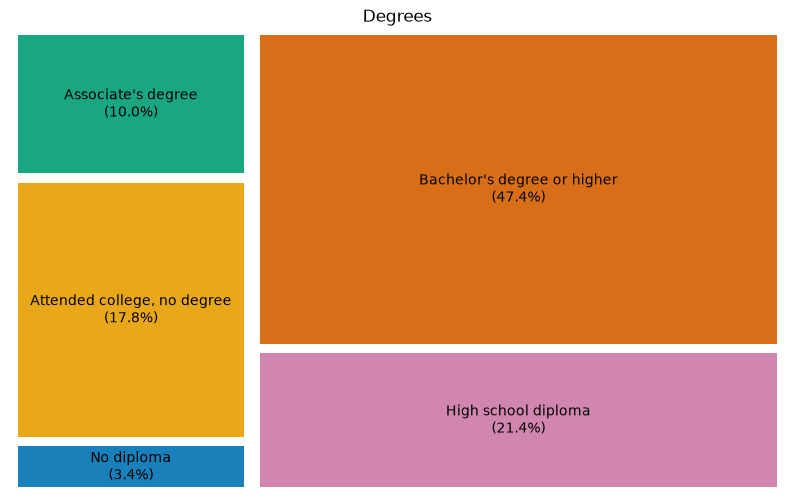

In [7]:
labels = [
    f'{name}\n({percent:.1f}%)'
    for name, percent in education_percent.items()]

colors = ['#0072B2','#E69F00','#009E73','#CC79A7','#D55E00']

plt.figure(figsize=(10, 6))

squarify.plot(
    sizes=education_counts.values,
    label=labels,
    color=colors,
    alpha=0.9,
    pad=True)

plt.title('Degrees')
plt.axis('off')
plt.show()

In [8]:
filtered_df = df[df['Age'] < 65]

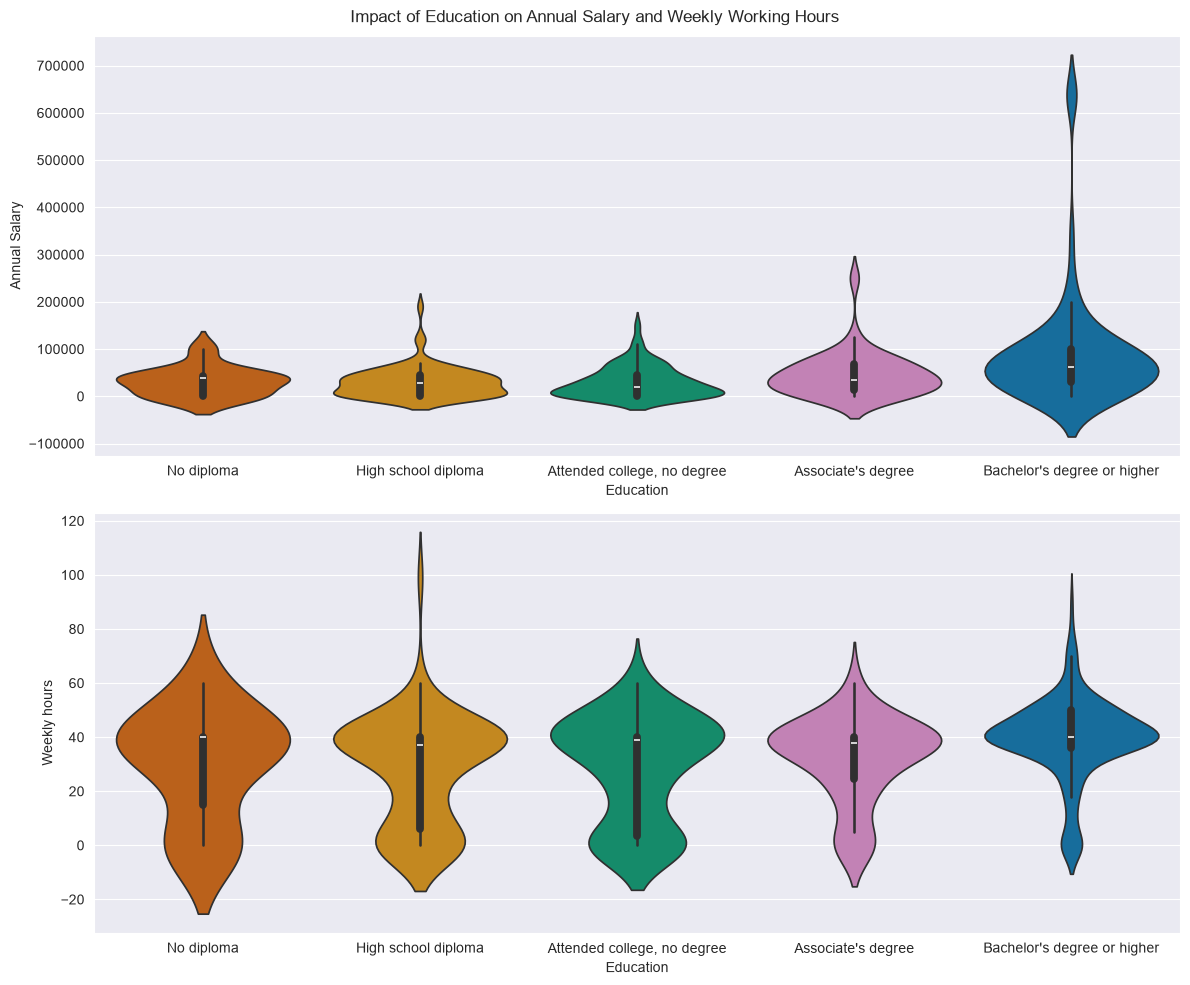

In [9]:
sns.set_style('darkgrid')

education_order = [
    'No diploma',
    'High school diploma',
    'Attended college, no degree',
    "Associate's degree",
    "Bachelor's degree or higher"]

fig, axes = plt.subplots(2, 1, figsize=(12, 10))

sns.violinplot(
    data=filtered_df,
    x='Education',
    y='Annual Salary',
    order=education_order,
    hue='Education',
    palette='colorblind',
    legend=False,
    ax=axes[0])

axes[0].set_xlabel('Education')
axes[0].set_ylabel('Annual Salary')

sns.violinplot(
    data=filtered_df,
    x='Education',
    y='Weekly hours',
    order=education_order,
    hue='Education',
    palette='colorblind',
    legend=False,
    ax=axes[1])

axes[1].set_xlabel('Education')
axes[1].set_ylabel('Weekly hours')

fig.suptitle('Impact of Education on Annual Salary and Weekly Working Hours')

plt.tight_layout()
plt.show()